In [ ]:
import shutil
from pathlib import Path
from pprint import pprint

import cv2
import numpy as np
from cv2.typing import MatLike

from utils import (
    get_img,
    process_single_img,
    reset_author_dir,
    show_images,
    show_img,
)


In [ ]:
dataset_path = Path("./dataset")

source_path = dataset_path / "original-dataset/Train"
preprocessed_path = dataset_path / "preprocessed/zhafif"
works_path = dataset_path / "works/zhafif"

imgs_to_replace = [
    "healthy.114.jpg",
    "healthy.105.jpg",
    "healthy.108.jpg",
    "healthy.117.jpg",
    "healthy.127.jpg",
]

img_dict: dict[str, MatLike] = {}
try:
    for img_name in imgs_to_replace:
        img = get_img(preprocessed_path / img_name, flags=cv2.IMREAD_COLOR_RGB)
        img_dict[img_name] = img
    show_images(
        img_dict, suptitle="Images to Replace", hist_cfg={"show_hist": False}, cmap="brg"
    )
except FileNotFoundError:
    print("File sudah dipindahkan atau tidak ada")


In [ ]:
tmp_dir = Path("./tmp")

# move to tmp folder
for img_name in imgs_to_replace:
    img_path = preprocessed_path / img_name
    dest = tmp_dir / img_name
    img_path.move(dest)
    print(f"[INFO] Successfully moved {img_path} to {dest}")

In [ ]:
replacements = [
    "healthy.150.jpg",
    "healthy.151.jpg",
    "healthy.152.jpg",
    "healthy.153.jpg",
    "healthy.154.jpg",
]

# copy dari dataset original ke works
for img_name in replacements:
    src = source_path / img_name
    dst = works_path / img_name
    
    shutil.copy2(src, dst)
    print(f"[INFO] Successfully copied '{src}' into '{works_path}'")
print()

Berhasil memproses: healthy.150.jpg -> dataset\preprocessed\zhafif\healthy.150.jpg
Berhasil memproses: healthy.151.jpg -> dataset\preprocessed\zhafif\healthy.151.jpg
Berhasil memproses: healthy.152.jpg -> dataset\preprocessed\zhafif\healthy.152.jpg
Berhasil memproses: healthy.153.jpg -> dataset\preprocessed\zhafif\healthy.153.jpg
Berhasil memproses: healthy.154.jpg -> dataset\preprocessed\zhafif\healthy.154.jpg


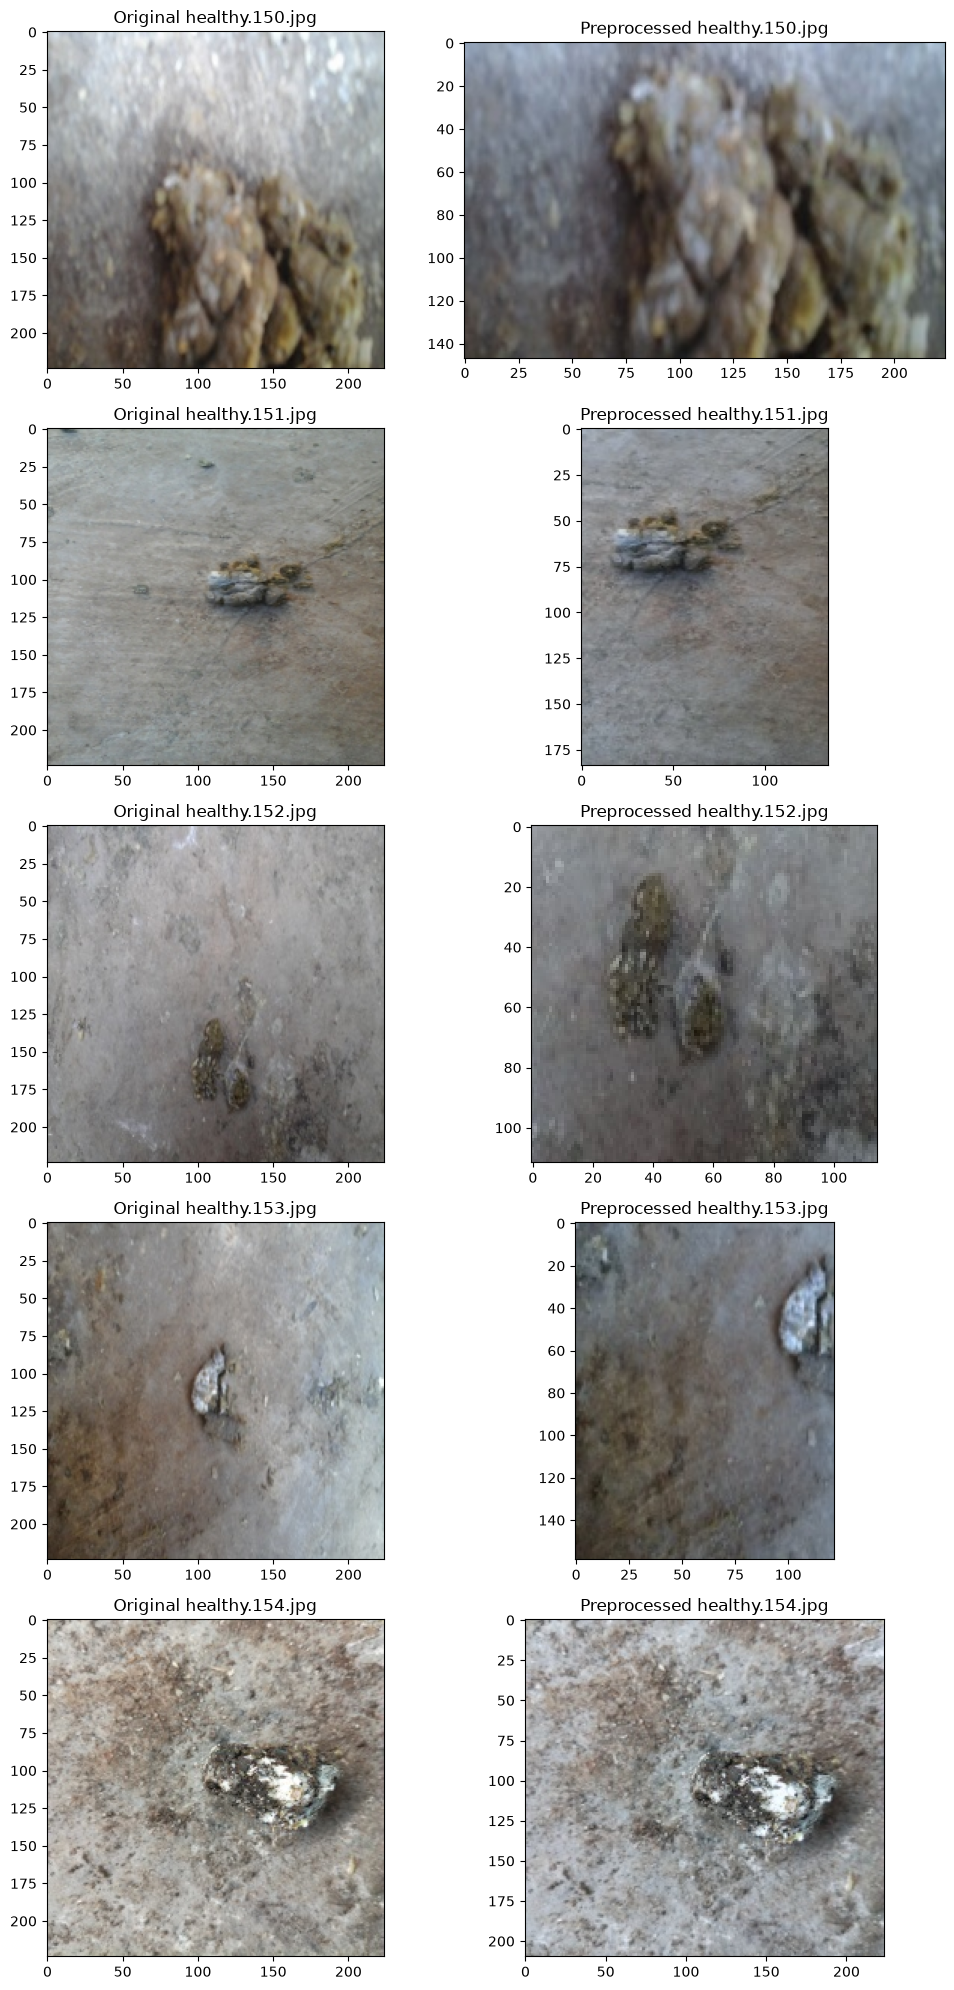

In [22]:
# lakukan preprocessing
results: dict[str, MatLike] = {}
for img_name in replacements:
    inpath = works_path / img_name
    outpath = preprocessed_path / img_name
    
    res = process_single_img(inpath, outpath, return_result=True)
    
    if res is not None:
        results[f"Original {img_name}"] = get_img(inpath, flags=cv2.IMREAD_COLOR_RGB)
        results[f"Preprocessed {img_name}"] = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)

show_images(results, ncols=2, hist_cfg={"show_hist": False}, cmap=None)